In [12]:
%load_ext autoreload
%autoreload 2

import os
import tempfile

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import colapy


def extract_nucleons_numpy(particles: list[Any]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Match ``datasets.data_io.extract_nucleons_numpy``: ``pos`` is ``(N, 4)`` as ``(t, x, y, z)`` (fm/c, fm)."""
    pos, mom, is_proton = [], [], []
    for p in particles:
        if p.pdg_code == 2212:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(True)
        elif p.pdg_code == 2112:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(False)
    if not pos:
        return np.zeros((0, 4), np.float64), np.zeros((0, 4), np.float64), np.zeros((0,), bool)
    return np.asarray(pos, np.float64), np.asarray(mom, np.float64), np.asarray(is_proton, bool)


class W(colapy.WriterBase):
    events = []

    def __init__(self, **kwargs):
        self.events.clear()

    def __call__(self, event_data):
        self.events.append(event_data)

def try_make_urqmd_event_generator():
    CONFIG = """
<?xml version="1.0" encoding="UTF-8" ?>
<program>
    <generator name="URQMDGenerator"
        pro="197 79"
        tar="197 79"
        nev="1"
        imp="5."
        elb="100."
        tim="200 200"
        generated_config_file="input_file"/>
    <writer name="PythonWriter" class="W"/>
</program>
"""

    def gen_one():
        with tempfile.NamedTemporaryFile(mode="w", suffix=".xml", delete_on_close=False) as tmp:
            tmp.write(CONFIG)
            tmp.close()
            rm = colapy.RunManager().load_module("COLA-Py").load_module("COLA_UrQMD").load_config(tmp.name)
            rm.run(1)
            if os.path.exists("input_file"):
                os.remove("input_file")
        if not W.events:
            return np.zeros((0, 4)), np.zeros((0, 4)), np.zeros((0,), bool)
        ev = W.events[-1]
        pos, mom, isp = extract_nucleons_numpy(ev.particles)
        return pos, mom, isp

    return gen_one


URQMD_GEN = try_make_urqmd_event_generator()


## Baseline clustering: Coalescence


In [ ]:
from pathlib import Path

import numpy as np

from cluster_energy import partition_loss_numpy
from models import (
    Q_CUT_MEVC,
    R_CUT_FM,
    baseline_clusters_numpy,
    load_valid_events_from_pkl,
)


def baseline_labels_and_partition(
    pos: np.ndarray,
    mom: np.ndarray,
    isp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[list[int]]]:
    """Align lengths; return (pos_n, mom_n, isp_n, baseline_partition)."""
    n0 = min(pos.shape[0], mom.shape[0], isp.shape[0])
    pos_n = np.asarray(pos[:n0], dtype=np.float64)
    mom_n = np.asarray(mom[:n0], dtype=np.float64)
    isp_n = np.asarray(isp[:n0], dtype=bool)
    n = pos_n.shape[0]
    if n < 2:
        return pos_n, mom_n, isp_n, []
    part = baseline_clusters_numpy(pos_n, mom_n, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
    return pos_n, mom_n, isp_n, part


def labels_from_partition(n: int, part: list[list[int]]) -> np.ndarray:
    lab = np.zeros(n, dtype=np.int32)
    for ci, c in enumerate(part):
        for j in c:
            lab[j] = ci
    return lab


def benchmark_baseline_on_events(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
) -> None:
    l_list: list[float] = []
    for pos, mom, isp in events:
        n = pos.shape[0]
        if n < 2:
            continue
        part = baseline_clusters_numpy(pos, mom, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
        l_list.append(float(partition_loss_numpy(pos, mom, isp, part)))
    if not l_list:
        print("No events with n≥2 in slice.")
        return
    l_mev = np.asarray(l_list, dtype=np.float64)
    n_in = len(events)
    print(
        f"Baseline (slice len={n_in}, evaluated n = {len(l_list)}): "
        f"partition loss = {l_mev.mean():.1f} ± {l_mev.std():.1f} MeV"
    )


_VALID_EVENTS = load_valid_events_from_pkl(Path("datasets") / "urqmd_nucleons_1k" / "dataset.pkl")


In [15]:
benchmark_baseline_on_events(_VALID_EVENTS[:64])


Baseline (slice len=64, evaluated n = 64): partition loss = -165.1 ± 229.2 MeV


## Baseline clustering: Visualization


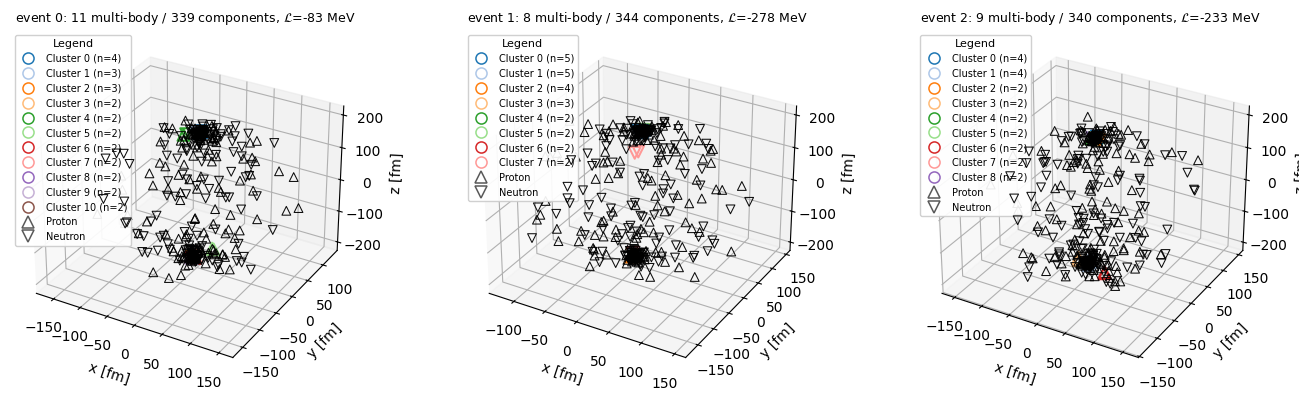

In [16]:
from matplotlib.lines import Line2D


def _tab20_sample(i: int) -> tuple:
    """Distinct ``tab20`` color for multi-body cluster rank ``i`` (cycles every 20)."""
    cmap = plt.get_cmap("tab20")
    n = int(getattr(cmap, "N", 20))
    t = (float(i % n) + 0.5) / float(n)
    return cmap(t)


def plot_baseline_clusterings_preview(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
    *,
    seed: int = 0,
) -> None:
    if not events:
        print("No events to visualize.")
        return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(events), size=len(events), replace=False)
    ncols = min(3, len(events))
    nrows = int(np.ceil(len(events) / ncols))
    fig = plt.figure(figsize=(4.6 * ncols, 4.0 * nrows))
    z_back, z_front = 1, 25
    s_single, lw_single = 40, 0.75
    s_multi, lw_multi = 72, 1.45
    edge_w_leg = 1.1
    for j, ii in enumerate(idx):
        pos, mom, isp = events[int(ii)]
        pos_n, mom_n, isp_n, part = baseline_labels_and_partition(pos, mom, isp)
        n = pos_n.shape[0]
        ax = fig.add_subplot(nrows, ncols, j + 1, projection="3d")
        if n < 2 or not part:
            ax.set_title(f"event {int(ii)}: n<2 or empty", fontsize=9)
            continue
        lab = labels_from_partition(n, part)
        cluster_sizes = np.array([len(c) for c in part], dtype=int)
        singleton = cluster_sizes[lab] == 1
        L_part = float(partition_loss_numpy(pos_n, mom_n, isp_n, part))
        pr = isp_n
        ne = ~isp_n
        multi_ids = sorted(ci for ci, c in enumerate(part) if len(c) > 1)
        ci_to_rgba = {ci: _tab20_sample(rank) for rank, ci in enumerate(multi_ids)}
        # Background: singletons (draw first, smaller).
        for mask, marker in ((pr, "^"), (ne, "v")):
            ms = mask & singleton
            if np.any(ms):
                ax.scatter(
                    pos_n[ms, 0],
                    pos_n[ms, 1],
                    pos_n[ms, 2],
                    facecolors="none",
                    edgecolors="black",
                    marker=marker,
                    s=s_single,
                    linewidths=lw_single,
                    alpha=0.95,
                    zorder=z_back,
                    depthshade=True,
                )
        # Foreground: multi-body clusters (draw last, larger, no depth fade).
        for mask, marker in ((pr, "^"), (ne, "v")):
            mm = mask & ~singleton
            if np.any(mm):
                idx_mm = np.flatnonzero(mm)
                ec = np.array([ci_to_rgba[int(lab[i])] for i in idx_mm], dtype=float)
                ax.scatter(
                    pos_n[mm, 0],
                    pos_n[mm, 1],
                    pos_n[mm, 2],
                    facecolors="none",
                    edgecolors=ec,
                    marker=marker,
                    s=s_multi,
                    linewidths=lw_multi,
                    alpha=1.0,
                    zorder=z_front,
                    depthshade=False,
                )
        ax.set_xlabel("x [fm]")
        ax.set_ylabel("y [fm]")
        ax.set_zlabel("z [fm]")
        n_multi = int(np.sum(cluster_sizes > 1))
        ax.set_title(
            rf"event {int(ii)}: {n_multi} multi-body / {len(part)} components, "
            rf"$\mathcal{{L}}$={L_part:.0f} MeV",
            fontsize=9,
        )
        handles: list[Line2D] = []
        for ci in multi_ids:
            rgba = ci_to_rgba[ci]
            handles.append(
                Line2D(
                    [0],
                    [0],
                    linestyle="none",
                    marker="o",
                    markersize=8.0,
                    markerfacecolor="none",
                    markeredgecolor=rgba,
                    markeredgewidth=edge_w_leg,
                    label=f"Cluster {ci} (n={len(part[ci])})",
                )
            )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="^",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Proton",
            )
        )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="v",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Neutron",
            )
        )
        ax.legend(
            handles=handles,
            loc="upper left",
            fontsize=7,
            framealpha=0.92,
            title="Legend",
            title_fontsize=8,
        )
    plt.tight_layout()
    plt.show()


plot_baseline_clusterings_preview(_VALID_EVENTS[:3], seed=1)


## Supervised on baseline: KNN graph


In [17]:
from pathlib import Path
from datetime import datetime

import numpy as np

from training.utils import make_event_sampler

TB_NOTEBOOK_ROOT = Path("runs") / "notebook"
TB_SESSION_DIR = TB_NOTEBOOK_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
TB_SESSION_DIR.mkdir(parents=True, exist_ok=True)

EVENT_SAMPLER = make_event_sampler(
    events=_VALID_EVENTS, rng=np.random.default_rng(42), fallback_urqmd=None
)

# Validation subset for TensorBoard (slice here to cap validation cost).
VAL_TENSORBOARD_EVENTS = _VALID_EVENTS[:256]


In [18]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger

supervised_env = AffinityGraphEnv(KNNGraphBuilder(k=4), CoalescenceHeuristicModel())
supervised_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
tb_sup_knn = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_knn6")
try:
    sup_hist = train_supervised_edges(
        supervised_policy,
        supervised_env,
        EVENT_SAMPLER,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_knn.log_supervised,
    )
finally:
    tb_sup_knn.close()
print(
    "last partition loss (MeV):",
    sup_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    sup_hist["pretrain_pos_recall_05"][-1],
)


SupEdges: 100%|██████████| 80/80 [00:47<00:00,  1.68it/s, bce=0.0333, L_pol=-0.874, L_base=-0.155, gap=-0.719, posRec=0.97, pOn=0.0608]  

last gap MeV: -719.0281211330816 | recall@0.5: 0.9698295985060692


## Supervised on baseline: radius graph (r = 1.15)

In [ ]:
import numpy as np

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    RadiusGraphBuilder,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

radius_env = AffinityGraphEnv(RadiusGraphBuilder(radius_norm=1.15), CoalescenceHeuristicModel())
radius_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
rng_radius = np.random.default_rng(43)
sampler_radius = make_event_sampler(
    events=_VALID_EVENTS, rng=rng_radius, fallback_urqmd=None
)

tb_sup_radius = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_radius_115")
try:
    radius_hist = train_supervised_edges(
        radius_policy,
        radius_env,
        sampler_radius,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_radius.log_supervised,
    )
finally:
    tb_sup_radius.close()
print(
    "radius r=1.15 | last partition loss (MeV):",
    radius_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    radius_hist["pretrain_pos_recall_05"][-1],
)


SupEdges: 100%|██████████| 80/80 [00:42<00:00,  1.86it/s, bce=0.0225, L_pol=-0.527, L_base=-0.295, gap=-0.232, posRec=1, pOn=1]       

radius r=1.15 | last gap MeV: -231.65447383954574 | recall@0.5: 1.0


## Supervised on baseline: full graph

In [ ]:
import numpy as np

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    FullGraphBuilder,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

full_env = AffinityGraphEnv(FullGraphBuilder(), CoalescenceHeuristicModel())
full_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
rng_full = np.random.default_rng(44)
sampler_full = make_event_sampler(
    events=_VALID_EVENTS, rng=rng_full, fallback_urqmd=None
)

tb_sup_full = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_full")
try:
    full_hist = train_supervised_edges(
        full_policy,
        full_env,
        sampler_full,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=15,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_full.log_supervised,
    )
finally:
    tb_sup_full.close()
print(
    "full graph | last partition loss (MeV):",
    full_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    full_hist["pretrain_pos_recall_05"][-1],
)


SupEdges: 100%|██████████| 80/80 [02:04<00:00,  1.55s/it, bce=0.00175, L_pol=-1.76, L_base=-0.242, gap=-1.52, posRec=0.812, pOn=0.000788]   

full graph | last gap MeV: -1519.7627316145586 | recall@0.5: 0.8122780004435628


## RL: REINFORCE


In [22]:
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.reinforce import train_reinforce
from training.tensorboard import TensorBoardHistoryLogger

In [23]:
from pathlib import Path

PRETRAINED_POLICY_CKPT = Path(".cache/sup_knn6_datasets__urqmd_nucleons_1k__dataset.pt")
RL_KNN = 6


In [30]:
env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=1,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=80,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
)
# policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

N_REINFORCE_UPDATES = 120
REINFORCE_LR = 3e-4

train_opt = optim.Adam(policy.parameters(), lr=REINFORCE_LR)
eta_min = min(1e-5, max(1e-10, float(REINFORCE_LR) * 0.05))
train_sched = CosineAnnealingLR(train_opt, T_max=N_REINFORCE_UPDATES, eta_min=eta_min)

tb_rf = TensorBoardHistoryLogger(TB_SESSION_DIR / "reinforce")
try:
    history = train_reinforce(
        policy,
        env,
        EVENT_SAMPLER,
        optimizer=train_opt,
        lr_scheduler=train_sched,
        n_updates=N_REINFORCE_UPDATES,
        episodes_per_update=32,
        ent_coef=0.02,
        max_grad_norm=1.2,
        policy_coef=1,
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_rf.log_reinforce,
    )
finally:
    tb_rf.close()


REINFORCE: 100%|██████████| 120/120 [04:54<00:00,  2.46s/it, pi=6.89, H=0.408, lr=1e-5, Rmean=2.4, G=2.4, L_pol=-2.4, L_base=-0.178, n_cl=314]            


## RL: A2C

In [ ]:
from training.a2c import train_actor_critic
from training.tensorboard import TensorBoardHistoryLogger


In [28]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityActorCritic,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.supervised import train_supervised_edges

env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=120,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
)
# policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

ac = GATAffinityActorCritic(policy)

N_A2C_UPDATES = 120
lr_a2c = 3e-4
a2c_opt = optim.Adam(ac.parameters(), lr=lr_a2c)
eta_min_a2c = min(1e-5, max(1e-8, lr_a2c * 0.05))
a2c_sched = CosineAnnealingLR(a2c_opt, T_max=N_A2C_UPDATES, eta_min=eta_min_a2c)

tb_a2c = TensorBoardHistoryLogger(TB_SESSION_DIR / "a2c")
try:
    history_a2c = train_actor_critic(
        ac,
        env,
        EVENT_SAMPLER,
        optimizer=a2c_opt,
        lr_scheduler=a2c_sched,
        n_updates=N_A2C_UPDATES,
        episodes_per_update=32,
        ent_coef=0.012,
        value_coef=0.5,
        max_grad_norm=1.2,
        policy_coef=1,
        center_adv=True,
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=lambda h: tb_a2c.log_actor_critic(h, algo="a2c"),
        detach_value_features=False,
    )
finally:
    tb_a2c.close()


A2C: 100%|██████████| 120/120 [04:40<00:00,  2.34s/it, pi=54.3, Vloss=4.19e+7, H=0.28, lr=1e-5, Vroll=0.0116, G=5.48, L_pol=-5.48, L_base=-0.225, n_cl=308]        


### RL: PPO

In [27]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityActorCritic,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training import ValueWarmupConfig, train_ppo
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR


env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=80,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
)
# policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

ac_ppo = GATAffinityActorCritic(policy)

N_PPO_UPDATES = 120
lr_ppo = 3e-4
ppo_opt = optim.Adam(ac_ppo.parameters(), lr=lr_ppo)
eta_min_ppo = min(1e-5, max(1e-8, lr_ppo * 0.05))
ppo_sched = CosineAnnealingLR(ppo_opt, T_max=N_PPO_UPDATES, eta_min=eta_min_ppo)

tb_ppo = TensorBoardHistoryLogger(TB_SESSION_DIR / "ppo")
try:
    history_ppo = train_ppo(
        ac_ppo,
        env,
        EVENT_SAMPLER,
        optimizer=ppo_opt,
        lr_scheduler=ppo_sched,
        n_updates=N_PPO_UPDATES,
        episodes_per_update=32,
        ppo_epochs=2,
        clip_range=0.15,
        value_coef=0.5,
        ent_coef=0.02,
        policy_coef=1,
        max_grad_norm=1.2,
        normalize_advantage=False,
        detach_value_features=True,
        value_warmup=ValueWarmupConfig(steps=20),
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=lambda h: tb_ppo.log_actor_critic(h, algo="ppo"),
    )
finally:
    tb_ppo.close()


PPO: 100%|██████████| 120/120 [05:21<00:00,  2.68s/it, pi=-3.3e+3, Vloss=9.94e+6, kl=-0.00103, clip=0, H=0.328, lr=1e-5, Vroll=0.0428, G=3.33, L_pol=-3.33, L_base=-0.14, n_cl=305]          
